# ContinuousTimeRNN Testing with User-Friendly API

This notebook uses the simplified neurosignature API:
- `SystemGenerator` for easy system creation with presets
- `InputGenerator` for one-line synaptic input generation
- Operating regime presets (passive, weakly_active, active)

In [6]:
import numpy as np
np.random.seed(0)

import matplotlib.pyplot as plt
import neurosignature as ns

import seaborn as sns

sns.set_context("notebook")

# Disable scientific notation on y-axes
plt.rcParams["axes.formatter.useoffset"] = False

In [15]:
def relu(x):
    return np.maximum(0, x)

from neurosignature.systems.system_generator import generate_random_matrix
W_int = generate_random_matrix(16, 16, dist="normal", matrix_type="symmetric")
W_prop = generate_random_matrix(16, 16, dist="normal", matrix_type="symmetric")
W_u = relu(generate_random_matrix(16, 3, dist="normal", matrix_type="dense"))
W_o = relu(generate_random_matrix(4, 16, dist="normal", matrix_type="dense"))

system = ns.ContinuousTimeRNN(
    n_hidden=16,
    n_inputs=3,
    n_outputs=4,
    W_int=W_int,
    W_prop=W_prop,
    W_u=W_u,
    W_o=W_o,
    g=0.5,
    tau=0.1,
    V_rest=-65.0,
    polarity="excitatory",
    phi="tanh",
)

## 2. Easy Input Generation with InputGenerator

One-line synaptic input generation - combines Poisson spikes with synaptic kernel.

In [16]:
# Create input generator
input_gen = ns.InputGenerator(
    n_channels=system.n_inputs,
    rate_hz=50.0,  # Poisson firing rate
    tau_ms=2.0,  # Synaptic decay time constant (ms)
    dt_ms=0.1,
)

# Generate smooth synaptic currents
duration_ms = 300
currents = input_gen.generate(duration_ms=duration_ms)

print(f"Input currents shape: {currents.shape}")
print(f"Current range: [{currents.min():.2f}, {currents.max():.2f}]")

Input currents shape: (3000, 3)
Current range: [0.00, 0.72]


## 3. Simulate and Visualize

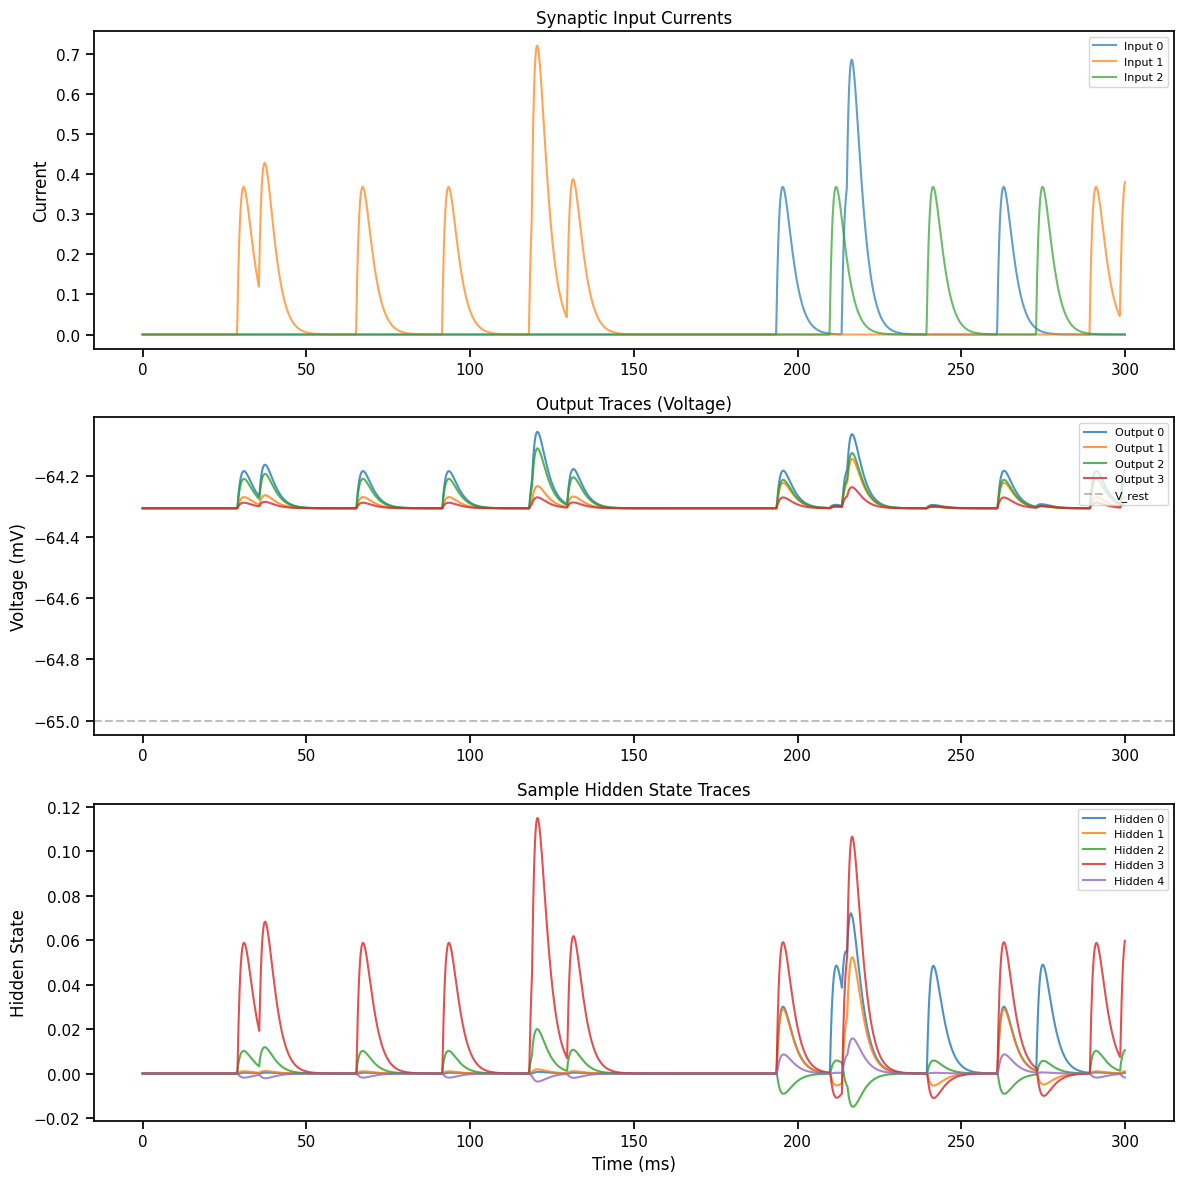

In [17]:
# Run simulation
simulator = ns.Simulator(system, dt_ms=0.1)
outputs, states = simulator.run(currents, record_states=True)

# Time axis
time = np.arange(len(outputs)) * simulator.dt_ms

# Plot
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# Plot input currents
ax = axes[0]
for i in range(min(system.n_inputs, 3)):
    ax.plot(time, currents[:, i], label=f"Input {i}", alpha=0.7)
ax.set_ylabel("Current")
ax.set_title("Synaptic Input Currents")
ax.legend(loc="upper right", fontsize=8)

# Plot outputs
ax = axes[1]
for i in range(min(system.n_outputs, 5)):
    ax.plot(time, outputs[:, i], label=f"Output {i}", alpha=0.8)
ax.axhline(system.V_rest, color="gray", linestyle="--", alpha=0.5, label="V_rest")
ax.set_ylabel("Voltage (mV)")
ax.set_title("Output Traces (Voltage)")
ax.legend(loc="upper right", fontsize=8)

# Plot a few hidden units
ax = axes[2]
for i in range(min(5, system.n_hidden)):
    ax.plot(time, states[:, i], label=f"Hidden {i}", alpha=0.8)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Hidden State")
ax.set_title("Sample Hidden State Traces")
ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()